# A Python Package for the Simultaneous Global Sensitivity Analysis of Foreground and Background Parameters in Life Cycle Assessment
**Jonathan Larochelle** (1,2), Laura Maria Comella (1,2)

1 Institute for Energy-Efficient Mobility (IEEM), Karlsruhe University of Applied Sciences

2 Faculty of mechatronics and mechanical engineering, Karlsruhe University of Applied Sciences

Wednesday September 23rd, 15:30

## Demonstration

### 0) Set-up
In case there was an issue with the environment, we ensure that required packages are installed.

In [2]:
%pip install -r requirements-w4-2-lcatoolbox.txt

  Cloning https://github.com/HKA-IES/lca_toolbox to c:\users\lajo0007\appdata\local\temp\pip-install-ep51s0gi\lcatoolbox_833ee2533cd84fa0964d22d1edda5810
  Resolved https://github.com/HKA-IES/lca_toolbox to commit 491dce8e3dac2636bb216c846479902b4290e191
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lcatoolbox: filename=lcatoolbox-0.1.0-py3-none-any.whl size=22755 sha256=3d6557ec65c7e029694cfc4f0f8f5a18602abaed23d5b19eb527a9e30a16cc67
  Stored in directory: C:\Users\lajo0007\AppData\Local\Temp\pip-ephem-wheel-cache-kedszcrn\wheels\34\74\bf\307cab41bfc072296c1bea69c0479a9747ba3f272d1cfef97d
Successfully built lcatoolbox
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/HKA-IES/lca_toolbox 'C:\Users\lajo0007\AppData\Local\Temp\pip-install-ep51s0gi\lcatoolbox_833ee2533cd84fa0964d22d1edda5810'

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


We then import the *lcatoolbox* package as well as brightway and other packages.

In [3]:
# Our package
import lcatoolbox

# Brightway
import bw2data as bd
from bw2data.parameters import ProjectParameter
import bw2io as bi

# Other packages
import matplotlib.pyplot as plt
import textwrap

C:\Users\lajo0007\code\brightcon-2026-material-fork\conference\wednesday\w4-2-ualca\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We set-up a brightway project. The .reset_foreground() function creates or resets the foreground database. By default, it has the name "foreground".

In [4]:
bd.projects.set_current("bc2026-w4-2-lcatoolbox")
lcatoolbox.reset_foreground()

We import the ecoinvent 3.12 database in the project, if it is not already present. We also apply some pre-processing to handle some weird uncertainties in the database. Specifically,
    - all uncertainties in exchanges that are not log-normal are replaced by no uncertainty;
    - geometric sigma for log-normal uncertainty in exchanges are capped at 4.

The same is done for the OpenLCA version of ecoinvent.

Note that is not recommended to place the ecoinvent username and password in plain text. Use the environment variables EI_USERNAME and EI_PASSWORD instead.

In [6]:
if 'ecoinvent-3.12-cutoff' in bd.databases:
    print('ecoinvent 3.12 is already present in the project')
    # del bd.databases['ecoinvent-3.12-cutoff']
    # del bd.databases['ecoinvent-3.12-biosphere']
else:
    bi.import_ecoinvent_release(
        username="USERNAME",
        password="PASSWORD",
        version='3.12',
        system_model='cutoff',
    )
    lcatoolbox.apply_openlca_preprocessing_to_ecoinvent("ecoinvent-3.12-cutoff")

Applying strategy: normalize_units
Applying strategy: drop_unspecified_subcategories
Applying strategy: ensure_categories_are_tuples
Applied 3 strategies in 0.01 seconds
Graph statistics for `ecoinvent-3.12-biosphere` importer:
9850 graph nodes:
	emission: 9477
	natural resource: 353
	inventory indicator: 15
	economic: 5
0 graph edges:
0 edges to the following databases:
0 unique unlinked edges (0 total):




100%|██████████| 9850/9850 [00:00<00:00, 36779.73it/s]


17:21:19+0200 [info     ] Vacuuming database            
Created database: ecoinvent-3.12-biosphere
Extracting XML data from 26533 datasets


100%|██████████| 26533/26533 [02:17<00:00, 192.44it/s]


17:23:40+0200 [info     ] Extracted 26533 datasets in 139.41 seconds
Applying strategy: normalize_units
Applying strategy: update_ecoinvent_locations
Applying strategy: remove_zero_amount_coproducts
Applying strategy: remove_zero_amount_inputs_with_no_activity
Applying strategy: remove_unnamed_parameters
Applying strategy: es2_assign_only_product_with_amount_as_reference_product
Applying strategy: assign_single_product_as_activity
Applying strategy: create_composite_code
Applying strategy: drop_unspecified_subcategories
Applying strategy: fix_ecoinvent_flows_pre35
Applying strategy: drop_temporary_outdated_biosphere_flows
Applying strategy: link_biosphere_by_flow_uuid
Applying strategy: link_internal_technosphere_by_composite_code
Applying strategy: delete_exchanges_missing_activity
Applying strategy: delete_ghost_exchanges
Applying strategy: remove_uncertainty_from_negative_loss_exchanges
Applying strategy: fix_unreasonably_high_lognormal_uncertainties
Applying strategy: convert_activ

100%|██████████| 26533/26533 [00:28<00:00, 925.82it/s] 


17:24:18+0200 [info     ] Vacuuming database            
Created database: ecoinvent-3.12-cutoff
26533 activities to update.
100 / 26533
200 / 26533
300 / 26533
400 / 26533
500 / 26533
600 / 26533
700 / 26533
800 / 26533
900 / 26533
1000 / 26533
1100 / 26533
1200 / 26533
1300 / 26533
1400 / 26533
1500 / 26533
1600 / 26533
1700 / 26533
1800 / 26533
1900 / 26533
2000 / 26533
2100 / 26533
2200 / 26533
2300 / 26533
2400 / 26533
2500 / 26533
2600 / 26533
2700 / 26533
2800 / 26533
2900 / 26533
3000 / 26533
3100 / 26533
3200 / 26533
3300 / 26533
3400 / 26533
3500 / 26533
3600 / 26533
3700 / 26533
3800 / 26533
3900 / 26533
4000 / 26533
4100 / 26533
4200 / 26533
4300 / 26533
4400 / 26533
4500 / 26533
4600 / 26533
4700 / 26533
4800 / 26533
4900 / 26533
5000 / 26533
5100 / 26533
5200 / 26533
5300 / 26533
5400 / 26533
5500 / 26533
5600 / 26533
5700 / 26533
5800 / 26533
5900 / 26533
6000 / 26533
6100 / 26533
6200 / 26533
6300 / 26533
6400 / 26533
6500 / 26533
6600 / 26533
6700 / 26533
6800 / 26533


### 1) Import foreground data
Our foreground data is contained in the spreadsheet foreground.ods. For the purposes of this demonstration, we do not introduce this case study in details. It will be the object of a future publication.

It is the comparative cradle-to-grave LCA of an environmental sensor. The two alternatives under consideration are a battery- and a solar-powered sensor.

In [7]:
new_activities = lcatoolbox.import_foreground("foreground.ods",
                                              data_quality_system="ciroth2016")

print("New activities:")
print(*new_activities, sep="\n")

act_battery_powered = bd.get_activity(name="Cradle-to-grave [battery-powered]")
act_solar_powered = bd.get_activity(name="Cradle-to-grave [solar-powered]")

New activities:
'Cradle-to-grave [battery-powered]' (item(s), DE, None)
'Cradle-to-grave [solar-powered]' (item(s), DE, None)
'Sensor assembly [common]' (item(s), DE, None)
'Sensor assembly [battery-powered]' (item(s), DE, None)
'Sensor assembly [solar-powered]' (item(s), DE, None)
'PCB assembly, power+sensor [common]' (item(s), DE, None)
'PCB assembly, power+sensor [battery-powered]' (item(s), DE, None)
'PCB assembly, power+sensor [solar-powered]' (item(s), DE, None)
'PCB assembly, mcu+lora' (item(s), DE, None)
'PCB assembly, solar cells' (item(s), DE, None)


We can also see that the import created many new parameters:

In [8]:
parameter_names = [p.name for p in ProjectParameter.select()]
print("Parameter names:")
print(parameter_names)

Parameter names:
['ic_ina234_die_area_mm2', 'ic_sip32432_die_area_mm2', 'ic_as7341_die_area_mm2', 'ic_shtc3_die_area_mm2', 'ic_tpsm83100s_die_area_mm2', 'ic_bq25570_die_area_mm2', 'ic_msp430fr5969_die_area_mm2', 'ic_die_to_mass_ratio_cm2_per_kg', 'cap_smd_0603_mass_mg', 'cap_smd_0805_mass_mg', 'cap_tht_35_8_mass_g', 'ind_smd_3816_mass_mg', 'ind_smd_2813_mass_mg', 'ind_smd_0805_mass_mg', 'res_smd_0805_mass_mg', 'res_smd_0603_mass_mg', 'res_smd_2512_mass_mg', 'led_smd_0603_mass_mg', 'switch_mass_mg', 'crystal_mass_mg', 'lambda62_mass_g', 'connector_2x6_mass_mg', 'connector_sma_mass_mg', 'connector_2x5_mass_mg', 'bat_AAA_mass_g', 'bat_holder_2x_AAA_mass_g', 'pcb_power_sensor_area_mm2', 'pcb_solar_cells_area_mm2', 'pcb_mcu_lora_area_mm2', 'conn_spring_piston_3pos_smd_mass_mg', 'solar_cell_area_mm2', 'antenna_mass_g', 'housing_volume_mm3', 'pcb_spacer_volume_mm3', 'lid_volume_mm3', 'resin_mass_density_g_per_cm3', 'extra_resin_3d_print', 'housing_mass_g', 'pcb_spacer_mass_g', 'lid_mass_g', '

Some of the names are cryptic, such as "exc\_{ID}\_data_quality", "exc\_{ID}\_amount", and "exc\_{ID}\_activity_fit". The ID corresponds to the unique ID of the exchange. You can use the function .get_exchange(ID) to find which parameter is associated to which exchange exactly.

In [9]:
lcatoolbox.get_exchange(358999599352344576)

Exchange: 80.0 item(s) 'Sensor assembly [battery-powered]' (item(s), DE, None) to 'Cradle-to-grave [battery-powered]' (item(s), DE, None)

### 2) Calculation of impacts

In [13]:
impact_categories = lcatoolbox.get_impact_categories("EF v3.1")

scores, parameters = lcatoolbox.calculate_scores(activities=[act_battery_powered, act_solar_powered],
                                     impact_categories=impact_categories)
scores

,activity,impact_category,value
0,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'acidification',...",9.843592e+00
1,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change'...",8.397329e+02
2,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change:...",1.380834e+00
3,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change:...",8.365748e+02
4,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'climate change:...",1.777259e+00
5,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'ecotoxicity: fr...",2.834018e+04
6,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'ecotoxicity: fr...",2.749844e+04
7,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'ecotoxicity: fr...",8.417421e+02
8,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'energy resource...",1.089931e+04
9,"('Cradle-to-grave [battery-powered]', None, 'D...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:...",9.705718e-01


### 3) Contributions analysis

In [15]:
lcatoolbox.contributions_tree(activity=act_battery_powered,
                              impact_category=impact_categories[1],
                              amount=1,
                              max_depth=2)

,activity_name,activity_location,parent_name,parent_location,depth,amount,unit,score,contribution
0,Cradle-to-grave [battery-powered],DE,NaN,NaN,0,1.000000e+00,item(s),839.732893,1.000000e+00
1,Sensor assembly [battery-powered],DE,Cradle-to-grave [battery-powered],DE,1,8.000000e+01,item(s),72.938439,8.685909e-02
2,"PCB assembly, power+sensor [battery-powered]",DE,Sensor assembly [battery-powered],DE,2,8.000000e+01,item(s),9.993985,1.190139e-02
3,"market for battery, NiMH, rechargeable",GLO,Sensor assembly [battery-powered],DE,2,2.080000e+00,kilogram,59.933795,7.137245e-02
4,"market for electric connector, peripheral type...",GLO,Sensor assembly [battery-powered],DE,2,3.200000e-01,kilogram,3.010658,3.585256e-03
5,Sensor assembly [common],DE,Cradle-to-grave [battery-powered],DE,1,8.000000e+01,item(s),642.937818,7.656456e-01
6,"PCB assembly, mcu+lora",DE,Sensor assembly [common],DE,2,8.000000e+01,item(s),441.416914,5.256635e-01
7,"PCB assembly, power+sensor [common]",DE,Sensor assembly [common],DE,2,8.000000e+01,item(s),44.625189,5.314212e-02
8,"market for electronic component, passive, unsp...",GLO,Sensor assembly [common],DE,2,2.320000e+00,kilogram,147.677723,1.758627e-01
9,market for injection moulding,GLO,Sensor assembly [common],DE,2,1.196745e+00,kilogram,1.493097,1.778062e-03


### 4) Uncertainty analysis and apportioning
We estimate the Sobol indices according to Li and Mahedevan (2016). This is done with random sampling, which means that
1) the background contributions will be considered, and
2) we can use the results to perform a normal uncertainty analysis.

For demonstration purposes, we use only $N=100$ samples. The calculation time per sample is high because
1) parameters are recalculated each time, and
2) the scores for each background processes are calculated as well.

In [21]:
ua_method = lcatoolbox.SobolLi2016Method(N=100, n_bins=10)
ua_results, ua_scores, ua_parameters = lcatoolbox.uncertainty_apportioning(activities=[act_solar_powered, act_battery_powered],
                                                                      impact_categories=impact_categories,
                                                                      method=ua_method)

Uncertainty Apportioning: |--------------------------------------------------| 1/100 (2.9 s elapsed, 291.6 s remaining)
Uncertainty Apportioning: |█-------------------------------------------------| 2/100 (5.6 s elapsed, 279.7 s remaining)
Uncertainty Apportioning: |█-------------------------------------------------| 3/100 (8.1 s elapsed, 265.9 s remaining)
Uncertainty Apportioning: |██------------------------------------------------| 4/100 (10.6 s elapsed, 259.4 s remaining)
Uncertainty Apportioning: |██------------------------------------------------| 5/100 (13.1 s elapsed, 254.3 s remaining)
Uncertainty Apportioning: |███-----------------------------------------------| 6/100 (15.6 s elapsed, 250.3 s remaining)
Uncertainty Apportioning: |███-----------------------------------------------| 7/100 (19.3 s elapsed, 262.1 s remaining)
Uncertainty Apportioning: |████----------------------------------------------| 8/100 (22.8 s elapsed, 268.1 s remaining)
Uncertainty Apportioning: |████----

We can plot the results for both activities for all impact categories. This is a lot...

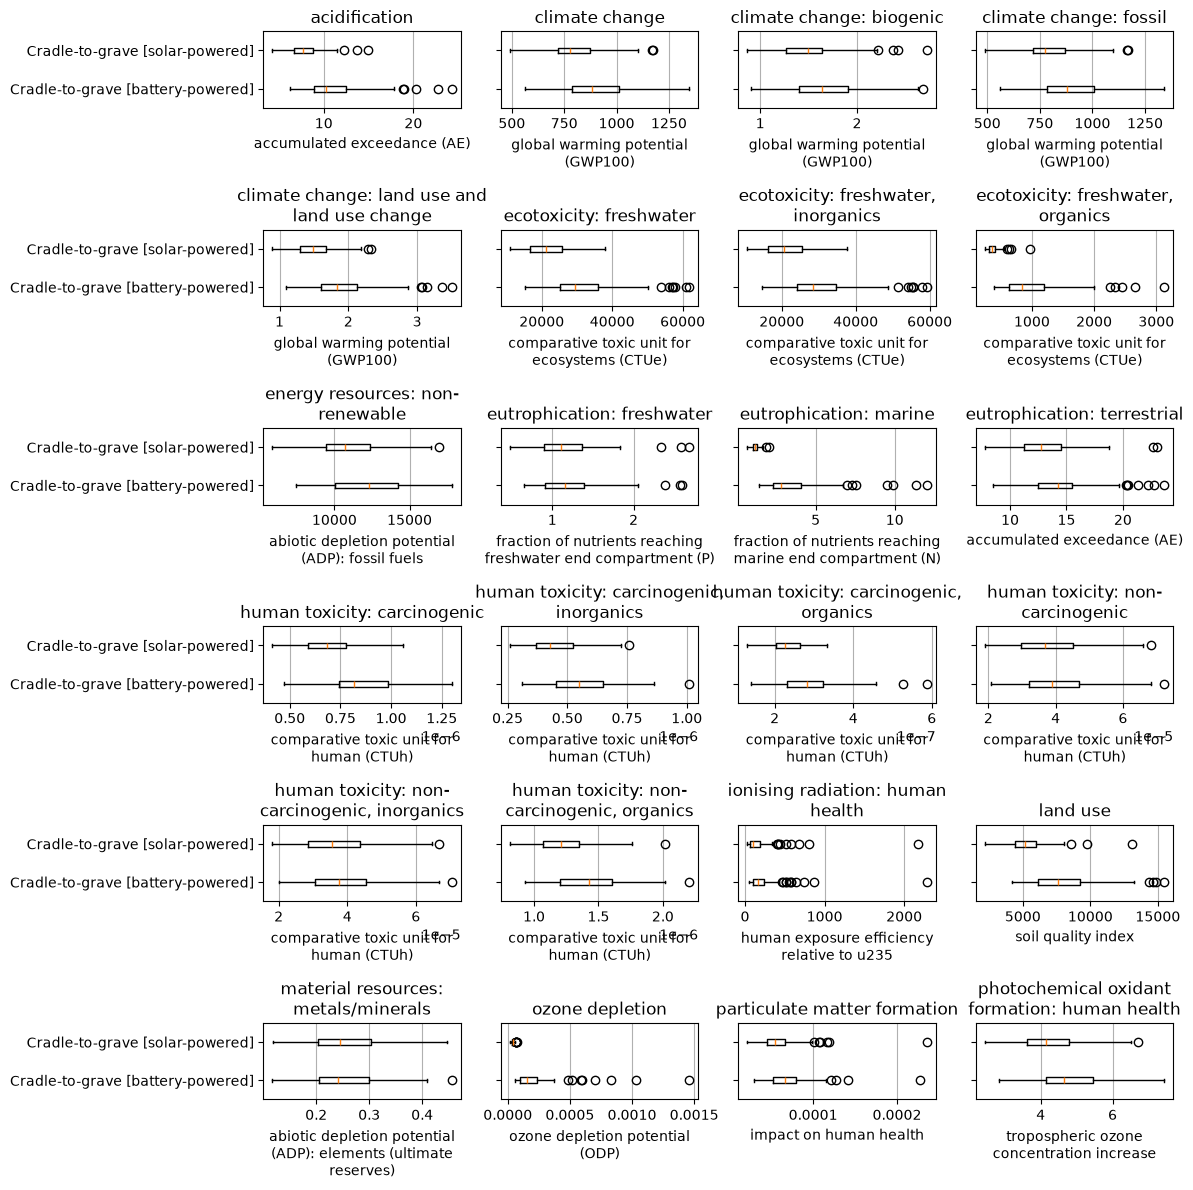

In [25]:
n_cols = 4
n_rows = int(len(impact_categories)/4)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axs = axs.flatten()

for ax, ic in zip(axs, impact_categories):
    ax.boxplot(x=ua_scores[(ua_scores["activity"] == lcatoolbox.activity_string(act_battery_powered)) &
                       (ua_scores["impact_category"] == str(ic))]["values"].values[0],
           orientation="horizontal",
           positions=[0])
    ax.boxplot(x=ua_scores[(ua_scores["activity"] == lcatoolbox.activity_string(act_solar_powered)) &
                       (ua_scores["impact_category"] == str(ic))]["values"].values[0],
           orientation="horizontal",
           positions=[1])
    ax.set_title(textwrap.fill(ic[2], width=30), wrap=True)
    ax.set_xlabel(textwrap.fill(ic[3], width=30))
    ax.grid(True, axis="x")
    ax.set_yticklabels([])

for i in range(n_rows):
    axs[i*4].set_yticks([0, 1], [act_battery_powered["name"], act_solar_powered["name"]])
plt.tight_layout()

And how discernible are both alternatives?

In [29]:
discernability = lcatoolbox.discernibility_analysis(ua_scores)
discernability[(discernability["activity_A"] == lcatoolbox.activity_string(act_battery_powered)) &
               (discernability["activity_B"] == lcatoolbox.activity_string(act_solar_powered))]

,activity_A,activity_B,impact_category,P_A>B,discernibility
25,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'acidification',...",1.00,1.00
650,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'climate change'...",0.82,0.64
1275,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'climate change:...",0.77,0.54
1900,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'climate change:...",0.82,0.64
2525,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'climate change:...",0.97,0.94
3150,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'ecotoxicity: fr...",1.00,1.00
3775,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'ecotoxicity: fr...",1.00,1.00
4400,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'ecotoxicity: fr...",1.00,1.00
5025,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'energy resource...",0.83,0.66
5650,"('Cradle-to-grave [battery-powered]', None, 'D...","('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:...",0.66,0.32


We see that the discernibility for impact category ('ecoinvent-3.12', 'EF v3.1', 'eutrophication: freshwater', 'fraction of nutrients reaching freshwater end compartment (P)') is low. We therefore look at the results of the uncertainty apportioning for each activity for this impact category.

We can look at the uncertainty apportioning for a single activity, or for the difference between two activities. The latter is more interesting, because some input factors might be common to both alternatives. In this case, reducing it will reduce the overall uncertainty, but not increase the discernibility.

First, we consider the solar-powered alternative alone:

In [34]:
target_ic = "('ecoinvent-3.12', 'EF v3.1', 'eutrophication: freshwater', 'fraction of nutrients reaching freshwater end compartment (P)')"
target_act = lcatoolbox.activity_string(act_solar_powered)

criteria = (ua_results["activity"] == target_act) & (ua_results["impact_category"] == target_ic)
ua_results[criteria].sort_values("S1_alg_2_rank", ascending=True)

,S1_alg_1,S1_alg_2,S1_alg_1_rank,S1_alg_2_rank,parameter,type,activity,impact_category
1145,0.593338,0.493338,1.0,1.0,"('market for integrated circuit, logic type', ...",background,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1140,0.576736,0.476736,2.0,2.0,"('market for printed wiring board, mounted mai...",background,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1146,0.548009,0.448009,3.0,3.0,"('market for electronic component, passive, un...",background,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1148,0.494086,0.394086,4.0,4.0,"('market for photovoltaic cell, single-Si wafe...",background,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1149,0.448942,0.348942,5.0,5.0,"('market for used Ni-metal hydride battery', '...",background,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
...,...,...,...,...,...,...,...,...
1078,0.055821,-0.044179,112.0,112.0,rubber_ring_antenna_volume_mm3,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1090,0.051586,-0.048414,113.0,113.0,exc_358999615315865600_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1119,0.046654,-0.053346,114.0,114.0,exc_358999646072696832_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
1046,0.038488,-0.061512,115.0,115.0,ic_as7341_die_area_mm2,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."


Note that the biggest contributors to the uncertainty are the underlying background contributions! If we had not ignored them, as is commonly done, we would have lost precious insights!

We now look at the factors which contribute most to the difference between both alternatives.

In [35]:
target_ic = "('ecoinvent-3.12', 'EF v3.1', 'eutrophication: freshwater', 'fraction of nutrients reaching freshwater end compartment (P)')"
target_act = f"{lcatoolbox.activity_string(act_solar_powered)} - {lcatoolbox.activity_string(act_battery_powered)}"

criteria = (ua_results["activity"] == target_act) & (ua_results["impact_category"] == target_ic)
ua_results[criteria].sort_values("S1_alg_2_rank", ascending=True)

,S1_alg_1,S1_alg_2,S1_alg_1_rank,S1_alg_2_rank,parameter,type,activity,impact_category
4002,0.388236,0.288236,1.0,1.0,exc_358999626300747776_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
3981,0.362199,0.262199,2.0,2.0,battery_lifetime,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
4054,0.251090,0.151090,3.0,3.0,"('market for mounting, surface mount technolog...",background,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
3983,0.232744,0.132744,4.0,4.0,exc_358999602229637120_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
4028,0.219905,0.119905,5.0,5.0,exc_358999653685358592_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
...,...,...,...,...,...,...,...,...
3991,0.040853,-0.059147,112.0,112.0,exc_358999616049868800_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
3957,0.035791,-0.064209,113.0,113.0,ind_smd_0805_mass_mg,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
3979,0.031353,-0.068647,114.0,114.0,rubber_ring_housing_volume_mm3,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."
3993,0.027986,-0.072014,115.0,115.0,exc_358999617530458112_activity_fit,foreground,"('Cradle-to-grave [solar-powered]', None, 'DE'...","('ecoinvent-3.12', 'EF v3.1', 'eutrophication:..."


In [36]:
lcatoolbox.get_exchange(358999626300747776)

Exchange: 0.033343135159613936 kilogram 'market for battery, NiMH, rechargeable' (kilogram, GLO, None) to 'Sensor assembly [battery-powered]' (item(s), DE, None)

The biggest contributors are
- exc_358999626300747776_activity_fit: fit of background process 'market for battery, NiMH, rechargeable';
- battery_lifetime: how long a battery lasts in the field;
- contribution of background process 'market for mounting, surface mount technology, Pb-free solder'

This gives us insights as to what we should refine next.

### 5) Wait a minute ... how should I handle multiple impact categories?
Good question. For each impact category, the ranking of factors will be different. We have also thought of a way to handle this and will shortly submit a paper on the subject.

If you are curious, our proposal is already implemented in the package. Feel free to dig around!

The paper will also investigate which uncertainty apportioning method has the fastest rank convergence.